In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 匯入必要的套件
import matplotlib.pyplot as plt

# 使用 fivethirtyeight 風格，讓圖表更美觀
# plt.style.use('fivethirtyeight')

# 設定字型，確保中文能正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 設定數學字型，確保負號能正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("./ex1.csv")

# 數值特徵
numeric_features = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]

# 類別特徵
categorical_features = ["Type1", "Type2", "Generation"]

# data.head(10)
# data.shape  多少資撩多燒欄位
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Number      168 non-null    int64  
 1   Name        168 non-null    str    
 2   Type1       168 non-null    str    
 3   Type2       79 non-null     str    
 4   HP          166 non-null    float64
 5   Attack      168 non-null    int64  
 6   Defense     168 non-null    int64  
 7   SpecialAtk  168 non-null    int64  
 8   SpecialDef  168 non-null    int64  
 9   Speed       168 non-null    int64  
 10  Generation  168 non-null    int64  
 11  Legendary   168 non-null    bool   
dtypes: bool(1), float64(1), int64(7), str(3)
memory usage: 14.7 KB


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer

numeric_data = data.loc[:, numeric_features].copy()
# numeric_data 有缺失直

numeric_data_without_missing = numeric_data.dropna(axis=0).copy()
# numeric_data_without_missing 去掉缺失值

stardard_scaler = StandardScaler()
stardard_scaled = stardard_scaler.fit_transform(numeric_data_without_missing)
# stardard_scaled 嘗試限縮範圍

stardard_scaled = pd.DataFrame(
    stardard_scaled,
    columns=numeric_features
)
# stardard_scaled 用成 dataframe
# display(stardard_scaled) 就可以 dataframe打在最後(?)

minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(numeric_data_without_missing)
minmax_scaled = pd.DataFrame(minmax_scaled, columns=numeric_features)

display(minmax_scaled)

,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,0.145833,0.237838,0.251429,0.279330,0.409091,0.222222
1,0.208333,0.308108,0.331429,0.363128,0.545455,0.333333
2,0.291667,0.416216,0.445714,0.474860,0.727273,0.481481
3,0.291667,0.513514,0.674286,0.597765,0.909091,0.481481
4,0.120833,0.254054,0.217143,0.251397,0.272727,0.370370
...,...,...,...,...,...,...
161,0.337500,0.697297,0.514286,0.474860,0.727273,0.481481
162,0.400000,0.567568,0.485714,0.776536,0.636364,0.851852
163,0.400000,1.000000,0.542857,0.776536,0.727273,0.851852
164,0.400000,0.783784,0.371429,1.000000,0.909091,0.925926


In [18]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import LabelEncoder

category_data = data.copy()
# category_data 還是原本的
# category_data.loc[:,["Name","Type1"]].head()
# loc 要拿欄位

type1_one_hot = pd.get_dummies(category_data["Type1"],prefix="Type1",dtype=int)
# display(type1_one_hot)
# 把type 抓出來看

label_encoder = LabelEncoder()
type1_label = label_encoder.fit_transform(category_data["Type1"])
type1_label = pd.DataFrame({
    "Type1": category_data["Type1"],
    "Type1_lable": type1_label
})
type1_label

,Type1,Type1_lable
0,Grass,7
1,Grass,7
2,Grass,7
3,Grass,7
4,Fire,5
...,...,...
163,Psychic,12
164,Psychic,12
165,Psychic,12
166,Grass,7


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

missing_data = data.copy()

# missing_data.isna().sum() 找出缺失總數

numeric_missing_data = missing_data.loc[:, numeric_features]
# numeric_missing_data

simple_imputer = SimpleImputer(strategy="median") # 用中位數補起來
simple_imputed = simple_imputer.fit_transform(
    numeric_missing_data
)
simple_imputed = pd.DataFrame(
    simple_imputed,
    columns=numeric_features
)
# simple_imputed

simple_imputer2 = SimpleImputer(
    strategy="constant",
    fill_value="NoType2"
    ) # 補我想要的
simple_imputed2 = simple_imputer2.fit_transform(
    missing_data.loc[:,["Type2"]]
)
simple_imputed2 = pd.DataFrame(
    simple_imputed2,
    columns=["Type2_imputed"]
)
# simple_imputed2

knn_imputer = KNNImputer(n_neighbors=3)
knn_imputed = knn_imputer.fit_transform(numeric_missing_data)
knn_imputed = pd.DataFrame(
    knn_imputed,
    columns=numeric_features
)
knn_imputed

# 用眾數或是中位數,會導致值過多,稀釋其他值
# 還有很多補值法
# 隨機森林

,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,45.000000,49.0,49.0,65.0,65.0,45.0
1,60.000000,62.0,63.0,80.0,80.0,60.0
2,80.000000,82.0,83.0,100.0,100.0,80.0
3,80.000000,100.0,123.0,122.0,120.0,80.0
4,39.000000,52.0,43.0,60.0,50.0,65.0
...,...,...,...,...,...,...
163,106.000000,190.0,100.0,154.0,100.0,130.0
164,106.000000,150.0,70.0,194.0,120.0,140.0
165,100.000000,100.0,100.0,100.0,100.0,100.0
166,69.666667,62.0,80.0,63.0,80.0,60.0


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


split_data = data.copy()

X = split_data.loc[:, numeric_features].copy()
y = split_data["Legendary"].astype(int).copy()

split_imputer = SimpleImputer(strategy="median")
x_filled = split_imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
        x_filled,
        y,
        test_size= 0.25, # 可以自己訂,留4分之一做test
        random_state=0, # 要能重現,而不是巧合
        stratify=y
)

# 注意：scaler 只能 fit 在訓練資料，不能偷看測試資料
# 拿已知資料的規律去做
split_scaler = StandardScaler()
X_train_scaled = split_scaler.fit_transform(X_train)
X_test_scaled = split_scaler.transform(X_test)

split_model = KNeighborsClassifier(n_neighbors=3)
split_model.fit(X_train_scaled, y_train) # .fit 就是訓練
print(split_model.score(X_train_scaled, y_train))
print(split_model.score(X_test_scaled, y_test))
# 正常來說不可能
# 因為這個資料太少
# 才會是 0.97 和 1

cv = KFold(n_splits=3, shuffle=True, random_state=0)
fold_results = []
fold_number = 1

for train_index, valid_index in cv.split(x_filled, y):
    X_fold_train = x_filled[train_index]
    X_fold_valid = x_filled[valid_index]
    y_fold_train = y.iloc[train_index]
    y_fold_valid = y.iloc[valid_index]

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_valid_scaled = fold_scaler.transform(X_fold_valid)

    fold_model = KNeighborsClassifier(n_neighbors=3)
    fold_model.fit(X_fold_train_scaled, y_fold_train)

    print(fold_number)
    print(fold_model.score(X_fold_train_scaled, y_fold_train))
    print(fold_model.score(X_fold_valid_scaled, y_fold_valid))
    fold_number += 1
    print("--" * 30)

0.9761904761904762
1.0
1
0.9821428571428571
0.9821428571428571
------------------------------------------------------------
2
0.9732142857142857
0.9464285714285714
------------------------------------------------------------
3
0.9821428571428571
0.9285714285714286
------------------------------------------------------------


In [ ]:
# ============================================================
# 6. 異常值偵測：Elliptic Envelope、IQR、Isolation Forest、LOF
# ============================================================

from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

outlier_data = data.copy()

# 先準備數值特徵，並填補遺漏值
outlier_imputer = SimpleImputer(strategy="median")
X_outlier = outlier_imputer.fit_transform(outlier_data.loc[:, numeric_features].values)

# 多數距離或邊界方法對尺度敏感，因此先標準化
outlier_scaler = StandardScaler()
X_outlier_scaled = outlier_scaler.fit_transform(X_outlier)

# 為了方便比較各種方法的結果，先把 Name 與數值特徵複製到 outlier_result DataFrame
outlier_result = outlier_data.loc[:, ["Name"] + numeric_features]

# outlier_result

# 1. Elliptic Envelope

ellipsic_model = EllipticEnvelope(
    contamination=0.05,
    random_state=0
)

outlier_result["EllipticEnvelope"] = ellipsic_model.fit_predict(X_outlier_scaled)

# ------------------------------------------------------------
# 2. IQR method：這裡用 HP 當作一維示範
# ------------------------------------------------------------
hp_series = outlier_result["HP"]

# 計算 HP 的第一四分位數
hp_q1 = hp_series.quantile(0.25)

# 計算 HP 的第三四分位數
hp_q3 = hp_series.quantile(0.75)

# 計算 HP 的四分位距
hp_iqr = hp_q3 - hp_q1

# 計算 HP 的下界與上界
hp_lower_bound = hp_q1 - 1.5 * hp_iqr

# 計算 HP 的上界
hp_upper_bound = hp_q3 + 1.5 * hp_iqr

# 預設先把 IQR_HP 欄位填成 1，代表非離群值
outlier_result["IQR_HP"] = 1

outlier_result.loc[outlier_result["HP"] < hp_lower_bound, "IQR_HP"] = -1
outlier_result.loc[outlier_result["HP"] > hp_upper_bound, "IQR_HP"] = -1

# 3. Isolation Forest
isolation_model = IsolationForest(
    contamination=0.05,
    random_state=0
    )

outlier_result["IsolationForest"] = isolation_model.fit_predict(X_outlier_scaled)

# 4. Local Outlier Factor
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_result["LOF"] = lof_model.fit_predict(X_outlier_scaled)
outlier_result["LOF_negative_score"] = lof_model.negative_outlier_factor_

print("各方法偵測到的離群值數量")
summary = pd.DataFrame()
summary["method"] = ["EllipticEnvelope", "IQR_HP", "IsolationForest", "LOF"]
summary["outlier_count"] = [
    (outlier_result["EllipticEnvelope"] == -1).sum(),
    (outlier_result["IQR_HP"] == -1).sum(),
    (outlier_result["IsolationForest"] == -1).sum(),
    (outlier_result["LOF"] == -1).sum()
]
display(summary)

print("被任一方法判定為離群值的資料：")
any_outlier = (
    (outlier_result["EllipticEnvelope"] == -1) |
    (outlier_result["IQR_HP"] == -1) |
    (outlier_result["IsolationForest"] == -1) |
    (outlier_result["LOF"] == -1)
)
# print(any_outlier.to_numpy())
display(outlier_result.loc[any_outlier].head(20))

# 但是也是有很多 -1, 但是卻是離群值
# 例如 吉利蛋

各方法偵測到的離群值數量


,method,outlier_count
0,EllipticEnvelope,9
1,IQR_HP,3
2,IsolationForest,9
3,LOF,9


被任一方法判定為離群值的資料：


,Name,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,EllipticEnvelope,IQR_HP,IsolationForest,LOF,LOF_negative_score
19,大針蜂Mega,65.0,150,40,15,80,145,1,1,-1,-1,-1.770435
44,胖丁,115.0,45,20,45,25,20,-1,1,-1,-1,-1.804923
45,胖可丁,140.0,70,45,85,50,45,-1,-1,1,-1,-1.592939
71,胡地Mega,55.0,50,65,175,95,150,1,1,-1,-1,-1.522397
87,呆殼獸Mega,95.0,75,180,130,80,30,-1,1,-1,-1,-1.732665
97,大舌貝,30.0,65,100,45,25,40,-1,1,1,1,-1.276313
98,刺甲貝,50.0,95,180,85,45,70,-1,1,-1,1,-1.490391
103,大岩蛇,35.0,45,160,30,45,70,-1,1,1,1,-1.486352
107,巨鉗蟹,55.0,130,115,50,50,75,-1,1,1,1,-1.231413
121,吉利蛋,250.0,5,5,35,105,50,-1,-1,-1,-1,-3.601411


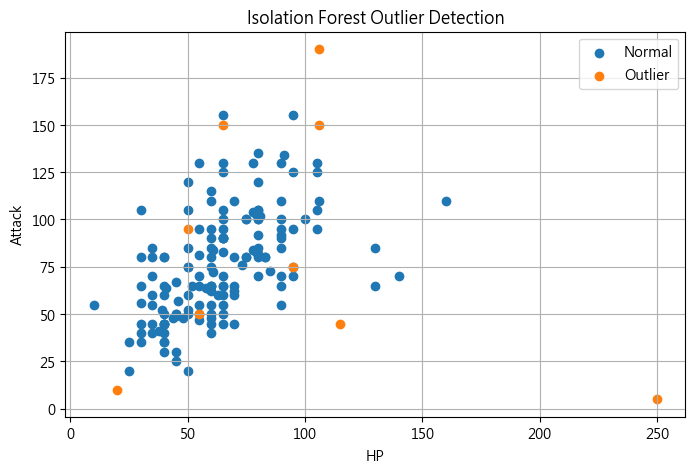

In [38]:
# 6. 異常值視覺化：使用 matplotlib

normal_points = outlier_result["IsolationForest"] == 1
outlier_points = outlier_result["IsolationForest"] == -1

plt.figure(figsize=(8, 5), dpi=100)

plt.scatter(
    outlier_result.loc[normal_points, "HP"],
    outlier_result.loc[normal_points, "Attack"],
    label = "Normal"
)

plt.scatter(
    outlier_result.loc[outlier_points, "HP"],
    outlier_result.loc[outlier_points, "Attack"],
    label = "Outlier"
)

plt.xlabel("HP")
plt.ylabel("Attack")
plt.title("Isolation Forest Outlier Detection")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
# ============================================================
# 7. 處理離群值與偵測新奇值
# ============================================================

from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

handling_data = data.copy()

# 方法 1：刪除 IsolationForest 判定的離群值
clean_data = handling_data.loc[outlier_result["IsolationForest"] == 1]
print("刪除離群值前的資料筆數：", handling_data.shape[0])
print("刪除離群值後的資料筆數：", clean_data.shape[0])

# 方法 2：新增離群值標示欄位

data_with_outlier_flag = handling_data
data_with_outlier_flag["is_otlier"] = 0
data_with_outlier_flag.loc[outlier_result["IsolationForest"] == -1, "is_outlier"] = 1

print("新增 is_outlier 欄位後：")
display(data_with_outlier_flag.loc[:, ["Name", "HP", "Attack", "is_outlier"]].head())

# 方法 3：轉換特徵值，降低極端值影響
# log1p(x) 等於 log(1 + x)，可以處理 x = 0 的情況
# 捨不得丟 outlier

transformed_data = handling_data
transformed_data["Attack_log1p"] = np.log1p(transformed_data["Attack"])
#print("Attack 轉換前後比較：")
#display(transformed_data.loc[:, ["Name", "Attack", "Attack_log1p"]].head())

# Novelty Detection：用正常資料訓練，再判斷新資料是否異常
normal_data_scaled = X_outlier_scaled[outlier_result["IsolationForest"].values == 1]

one_class_svm =OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
# kernel 像是一個胎記標記在那邊
# gamma 會越包越緊(?)
one_class_svm.fit(normal_data_scaled)

lof_novelty = LocalOutlierFactor(n_neighbors=20, novelty=True)
# novelty=True 才能預測新奇值
lof_novelty.fit(normal_data_scaled)
# 要對應上面寫的 數值型

newData = [
    [50, 55, 45, 60, 50, 60],
    [250, 250, 250, 250, 250, 250]
]

newData_scaled = outlier_scaler.transform(newData)

novelty_result = pd.DataFrame(newData, columns=numeric_features)
novelty_result["OneClassSVM_prediction"] = one_class_svm.predict(newData_scaled)
novelty_result["LOF_novelty_prediction"] = lof_novelty.predict(newData_scaled)

print("Novelty Detection 結果：1 代表正常，-1 代表可能異常")
display(novelty_result)

刪除離群值前的資料筆數： 168
刪除離群值後的資料筆數： 159
新增 is_outlier 欄位後：


,Name,HP,Attack,is_outlier
0,妙蛙種子,45.0,49,NaN
1,妙蛙草,60.0,62,NaN
2,妙蛙花,80.0,82,NaN
3,妙蛙花Mega,80.0,100,NaN
4,小火龍,39.0,52,NaN


Novelty Detection 結果：1 代表正常，-1 代表可能異常


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,OneClassSVM_prediction,LOF_novelty_prediction
0,50,55,45,60,50,60,1,1
1,250,250,250,250,250,250,-1,-1


In [54]:
# ============================================================
# 8. 選取重要特徵：VarianceThreshold、相關係數、卡方、ANOVA、MI
# ============================================================

from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import chi2
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

feature_data = data.copy()

X_numeric = feature_data.loc[:, numeric_features]
y_target = feature_data["Legendary"].astype(int) # 轉成int 型態

feature_imputer = SimpleImputer(strategy="median")
X_numeric_filled = feature_imputer.fit_transform(X_numeric)
X_numeric_filled = pd.DataFrame(X_numeric_filled, columns=numeric_features)

# 老師變異程度是設定0,只要有變異就要抓
# 變異程度可以以自己的經驗作設定

# X_numeric_filled 

# ------------------------------------------------------------
# 1. VarianceThreshold：觀察每個特徵的變異數
# ------------------------------------------------------------
# threshold=0.0 代表移除變異數為 0 的特徵，也就是完全沒有變化的特徵
# 可以透過 variance_selector.variances_ 來查看每個特徵的變異數值
variance_selector = VarianceThreshold(threshold=0.0) # 沒變動學不到東西
variance_selector.fit(X_numeric_filled)

variance_table = pd.DataFrame()
variance_table["feature"] = numeric_features
variance_table["variance"] = variance_selector.variances_
variance_table["keep_by_variance_threshold"] = variance_selector.get_support()

#print("VarianceThreshold 結果：")
#display(variance_table)

# ------------------------------------------------------------
# 2. 相關係數：數值型特徵 vs 目標 y
# -------------------------------------
correlation_table = pd.DataFrame()

correlation_table["Pearson"] = X_numeric_filled.corrwith(y_target, method="pearson")
correlation_table["Spearman"] = X_numeric_filled.corrwith(y_target, method="spearman")
correlation_table["Kendall"] = X_numeric_filled.corrwith(
    y_target, 
    method="kendall"
)

# print("數值特徵與 Legendary 的相關係數：")
# display(correlation_table)
# Defense	0.124347	0.172481	0.143693
# 跟 y 的相關程度最小,就可拿掉

# ------------------------------------------------------------
# 3. 卡方檢驗：類別型特徵 Type1 vs 類別型目標 Legendary
#    先將 Type1 做獨熱編碼，再計算 chi-square 分數
# ------------------------------------------------------------

type1_one_hot = pd.get_dummies(
    feature_data["Type1"],
    prefix="Type1",
    dtype=int
)
# type1_one_hot

chi2_scores, chi2_p_values = chi2(type1_one_hot, y_target)

chi2_table = pd.DataFrame()
chi2_table["feature"] = type1_one_hot.columns
chi2_table["chi2_score"] = chi2_scores
chi2_table["p_value"] = chi2_p_values
chi2_table = chi2_table.sort_values("chi2_score", ascending=False)

print("卡方檢驗結果：Type1 類別特徵 vs Legendary")
display(chi2_table.head(10))
# 小於0.05,就可以留
# why,看統計

# ------------------------------------------------------------
# 4. ANOVA F-value：數值型特徵 vs 類別型目標
# ------------------------------------------------------------
f_scores, f_p_values = f_classif(X_numeric_filled, y_target)

# ------------------------------------------------------------
# 5. Mutual Information：數值型特徵 vs 類別型目標
# ------------------------------------------------------------
mi_scores = mutual_info_classif(X_numeric_filled, y_target, random_state=0)

stat_table = pd.DataFrame()
stat_table["feature"] = numeric_features
stat_table["anova_f_score"] = f_scores
stat_table["anova_p_value"] = f_p_values
stat_table["mutual_information"] = mi_scores
stat_table = stat_table.sort_values("anova_f_score", ascending=False)

print("ANOVA F-value 與 Mutual Information 結果：")
display(stat_table)

卡方檢驗結果：Type1 類別特徵 vs Legendary


,feature,chi2_score,p_value
12,Type1_Psychic,17.942761,0.000023
9,Type1_Ice,12.518519,0.000403
2,Type1_Electric,1.485597,0.222901
14,Type1_Water,1.148148,0.283937
10,Type1_Normal,0.888889,0.345779
0,Type1_Bug,0.555556,0.456057
5,Type1_Fire,0.518519,0.471474
11,Type1_Poison,0.518519,0.471474
7,Type1_Grass,0.518519,0.471474
13,Type1_Rock,0.370370,0.542802


ANOVA F-value 與 Mutual Information 結果：


,feature,anova_f_score,anova_p_value,mutual_information
3,SpecialAtk,30.054808,1.537557e-07,0.042457
1,Attack,14.071027,2.429244e-04,0.021591
5,Speed,12.127207,6.352656e-04,0.014914
4,SpecialDef,10.478624,1.458134e-03,0.025778
0,HP,8.626084,3.784866e-03,0.044663
2,Defense,2.607035,1.082897e-01,0.026342


RFE 選取結果：


,feature,selected_by_RFE,RFE_ranking
0,HP,True,1
3,SpecialAtk,True,1
4,SpecialDef,True,1
2,Defense,False,2
5,Speed,False,3
1,Attack,False,4


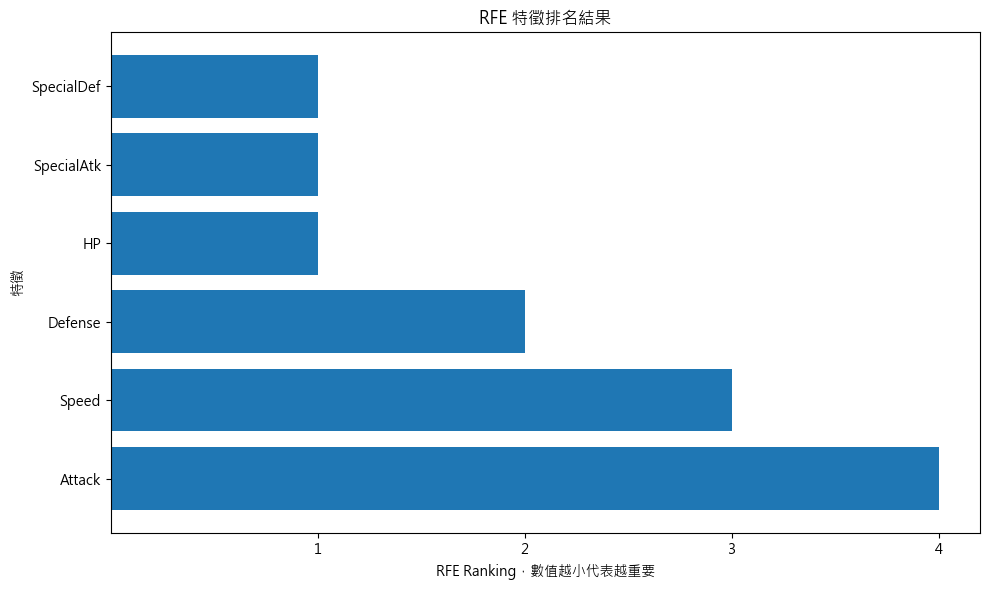

In [57]:
# ============================================================
# 9. 選取重要特徵：RFE 與 Permutation Feature Importance
# ============================================================

import matplotlib.pyplot as plt

from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

trial_data = data.copy()

X = trial_data.loc[:, numeric_features].copy()
y = trial_data["Legendary"].astype(int).copy()

trial_imputer = SimpleImputer(strategy="median")
X_filled = trial_imputer.fit_transform(X)

trial_scaler = StandardScaler()
X_scaled = trial_scaler.fit_transform(X_filled)

# ------------------------------------------------------------
# RFE：遞迴特徵汰除
# ------------------------------------------------------------
base_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=0
)
rfe_selector = RFE(estimator=base_model, n_features_to_select=3)
rfe_selector.fit(X_scaled, y)

rfe_table = pd.DataFrame()
rfe_table["feature"] = numeric_features
rfe_table["selected_by_RFE"] = rfe_selector.support_
rfe_table["RFE_ranking"] = rfe_selector.ranking_
rfe_table = rfe_table.sort_values("RFE_ranking")

print("RFE 選取結果：")
display(rfe_table)

# ------------------------------------------------------------
# RFE 視覺化
# ------------------------------------------------------------
# RFE_ranking 越小代表越重要。
# ranking = 1 代表最後被 RFE 選取的特徵。
rfe_plot_table = rfe_table.sort_values("RFE_ranking", ascending=False)

plt.figure(figsize=(10, 6))

plt.barh(
    rfe_plot_table["feature"],
    rfe_plot_table["RFE_ranking"]
)

plt.xlabel("RFE Ranking，數值越小代表越重要")
plt.ylabel("特徵")
plt.title("RFE 特徵排名結果")
plt.xticks(range(1, rfe_plot_table["RFE_ranking"].max() + 1))
plt.tight_layout()
plt.show()

Permutation Feature Importance 結果：


,feature,importance_mean,importance_std
5,Speed,0.100000,0.037665
3,SpecialAtk,0.076471,0.026956
0,HP,0.073529,0.049653
2,Defense,0.067647,0.054312
1,Attack,0.055882,0.030707
4,SpecialDef,0.041176,0.023529


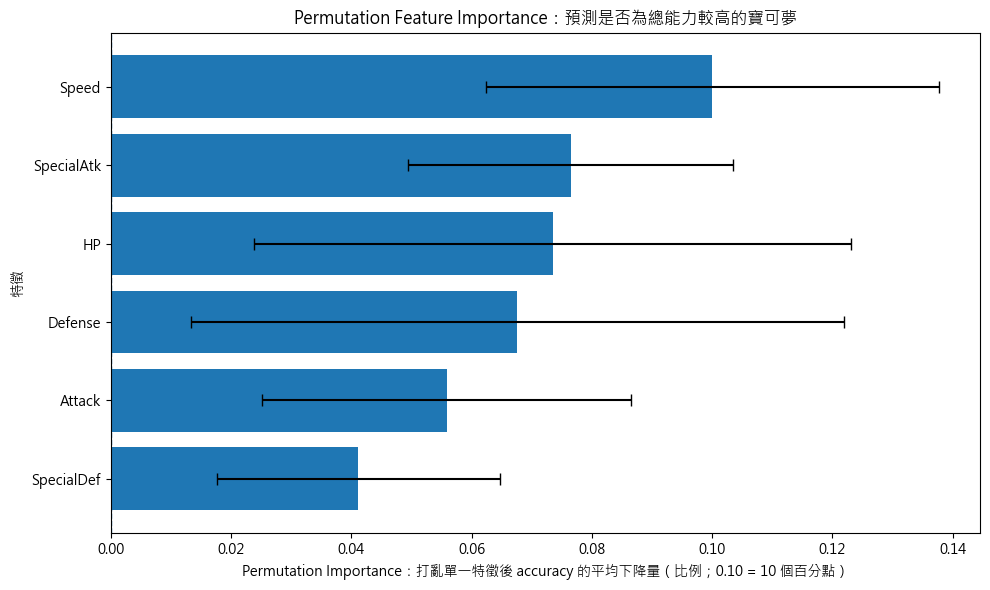

模型在測試資料上的 accuracy：
0.9705882352941176


In [61]:
# 先用 SimpleImputer 填補數值特徵的遺漏值。
label_imputer = SimpleImputer(strategy="median")
X_for_label_array = label_imputer.fit_transform(X)

# 將填補後的數值資料轉換回 DataFrame，方便後續計算總能力與切分類別。
X_for_label = pd.DataFrame(
    X_for_label_array,
    columns=numeric_features,
    index=X.index
)

# 六個能力值加總，作為總能力
total_power = (
    X_for_label["HP"]
    + X_for_label["Attack"]
    + X_for_label["Defense"]
    + X_for_label["SpecialAtk"]
    + X_for_label["SpecialDef"]
    + X_for_label["Speed"]
)
# print(total_power.to_numpy())

# 用中位數切成兩類：
# 低於中位數：0
# 高於或等於中位數：1
power_threshold = total_power.median()
y = (total_power >= power_threshold).astype(int)

# 將資料切分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)
# 先前補值是因為需要建立目標 y；
# 現在在訓練模型之前，再次對訓練集與測試集進行補值與標準化，
# 確保模型訓練過程中不會有遺漏值。
perm_imputer = SimpleImputer(strategy="median")
X_train_filled = perm_imputer.fit_transform(X_train)
X_test_filled = perm_imputer.transform(X_test)

# 將特徵標準化，確保計算過程中不會因為特徵尺度不同而影響結果。
perm_scaler = StandardScaler()
X_train_scaled = perm_scaler.fit_transform(X_train_filled)
X_test_scaled = perm_scaler.transform(X_test_filled)

# 使用 Logistic Regression 作為基礎模型，計算 Permutation Feature Importance
perm_model = LogisticRegression(
    max_iter=3000,
    random_state=0
)
perm_model.fit(X_train_scaled, y_train)

# 進行 Permutation Feature Importance 的計算
perm_result = permutation_importance(
    perm_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=0,
    scoring="accuracy"
)

perm_table = pd.DataFrame()
perm_table["feature"] = numeric_features
perm_table["importance_mean"] = perm_result.importances_mean
perm_table["importance_std"] = perm_result.importances_std
perm_table = perm_table.sort_values("importance_mean", ascending=False)

print("Permutation Feature Importance 結果：")
display(perm_table)

# ------------------------------------------------------------
# Permutation Feature Importance 視覺化
# ------------------------------------------------------------
# importance_mean 越大，代表打亂該特徵後，模型 accuracy 下降越多。
# 因此該特徵對模型越重要。
perm_plot_table = perm_table.sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    perm_plot_table["feature"],
    perm_plot_table["importance_mean"],
    xerr=perm_plot_table["importance_std"],
    capsize=4
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Permutation Importance：打亂單一特徵後 accuracy 的平均下降量（比例；0.10 = 10 個百分點）")
plt.ylabel("特徵")
plt.title("Permutation Feature Importance：預測是否為總能力較高的寶可夢")
plt.tight_layout()
plt.show()

print("模型在測試資料上的 accuracy：")
print(perm_model.score(X_test_scaled, y_test))

Logistic Regression coefficient 結果：


,feature,coefficient,abs_coefficient
0,HP,1.961914,1.961914
5,Speed,1.654520,1.654520
1,Attack,1.583030,1.583030
3,SpecialAtk,1.477098,1.477098
2,Defense,1.213075,1.213075
4,SpecialDef,0.738910,0.738910


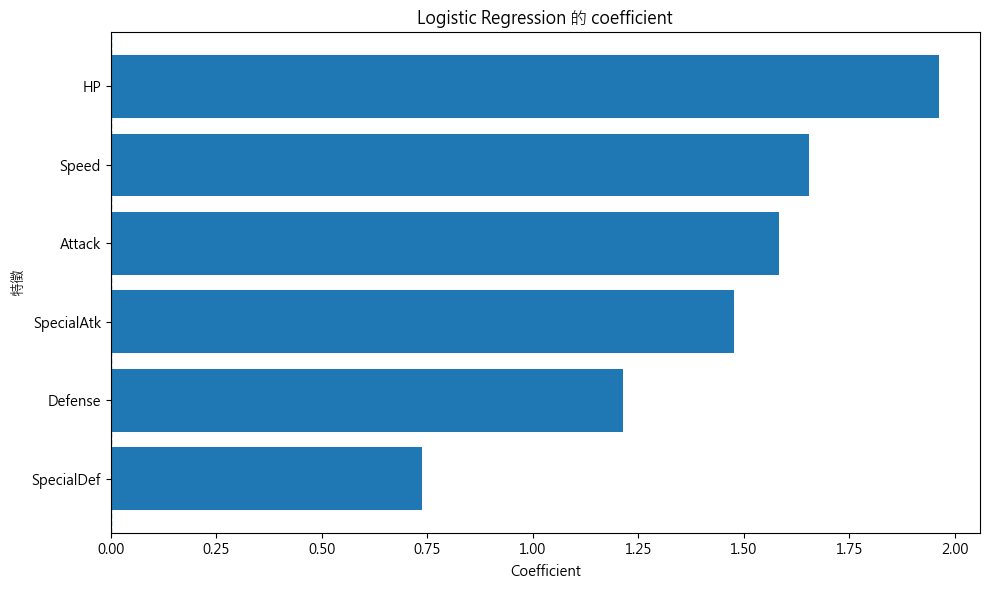

In [ ]:
# ============================================================
# 9. 補充範例：coefficient 與 feature_importances_
# ============================================================

# 最常見的回歸方法

from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# A. 線性模型：Logistic Regression 的 coef_
# ------------------------------------------------------------
# coef_ 是線性模型內部的係數。
# 在 Logistic Regression 中：
#   係數 > 0：特徵值越大，越傾向預測為 Legendary
#   係數 < 0：特徵值越大，越不傾向預測為 Legendary
#
# 注意：
# 因為 coef_ 會受到特徵尺度影響，
# 所以這裡使用前面已經標準化過的 X_train_scaled。
coef_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=0
)

coef_model.fit(X_train_scaled, y_train)
coef_model.coef_

coef_table = pd.DataFrame()
coef_table["feature"] = numeric_features
coef_table["coefficient"] = coef_model.coef_[0] # 看第一個特徵的權種
coef_table["abs_coefficient"] = abs(coef_model.coef_[0])

coef_table = coef_table.sort_values(
    "abs_coefficient",
    ascending=False
)

print("Logistic Regression coefficient 結果：")
display(coef_table)

# ------------------------------------------------------------
# coefficient 視覺化
# ------------------------------------------------------------
# 這張圖保留正負方向。
# 正值代表越傾向 Legendary；
# 負值代表越不傾向 Legendary。
coef_plot_table = coef_table.sort_values("coefficient", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    coef_plot_table["feature"],
    coef_plot_table["coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Coefficient")
plt.ylabel("特徵")
plt.title("Logistic Regression 的 coefficient")

plt.tight_layout()
plt.show()

Random Forest feature_importances_ 結果：


,feature,feature_importance
0,HP,0.220264
1,Attack,0.193586
4,SpecialDef,0.185301
5,Speed,0.147296
3,SpecialAtk,0.131367
2,Defense,0.122185


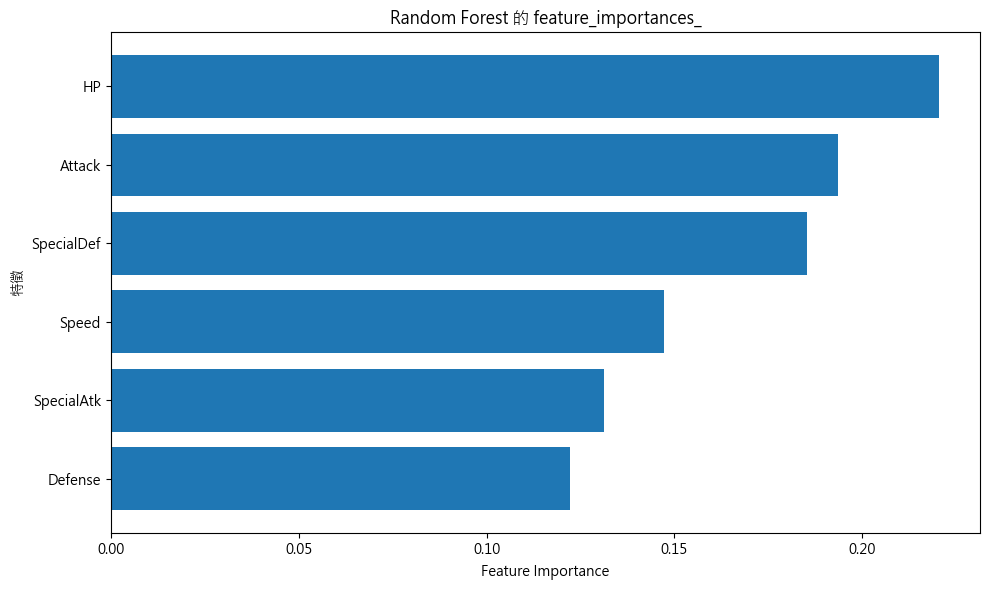

In [64]:
# B. 非線性模型：Random Forest 的 feature_importances_

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=0
)

rf_model.fit(X_train_filled, y_train)

rf_importance_table = pd.DataFrame()
rf_importance_table["feature"] = numeric_features
rf_importance_table["feature_importance"] = rf_model.feature_importances_

rf_importance_table = rf_importance_table.sort_values(
    "feature_importance",
    ascending=False
)

print("Random Forest feature_importances_ 結果：")
display(rf_importance_table)

# ------------------------------------------------------------
# feature_importances_ 視覺化
# ------------------------------------------------------------
rf_plot_table = rf_importance_table.sort_values(
    "feature_importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    rf_plot_table["feature"],
    rf_plot_table["feature_importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("特徵")
plt.title("Random Forest 的 feature_importances_")

plt.tight_layout()
plt.show()